In [1]:
#Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Project modules
from data_loader import load_data
from classical_models import run_random_forest
from feature_selection import select_top_features
from quantum_models import run_qsvc
from utils import print_section

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC


ModuleNotFoundError: No module named 'data_loader'

In [ ]:
#Loading dataset
print_section("Loading Dataset")

X_train, X_test, y_train, y_test, scaler = load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Loading Dataset
Training Shape: (242, 13)
Testing Shape: (61, 13)


In [ ]:

# FEATURE SELECTION 


print_section("Feature Selection for Quantum Model")

# Train Random Forest
rf_model = run_random_forest(X_train, y_train)

# Use function from feature_selection.py
X_train_q, X_test_q, selected_features = select_top_features(
    rf_model,
    X_train,
    X_test,
    k=4
)

print("Selected Features:", selected_features)
print("Quantum Training Shape:", X_train_q.shape)



Feature Selection for Quantum Model
Selected Quantum Features: ['cp', 'thalach', 'oldpeak', 'thal']
Selected Features: ['cp', 'thalach', 'oldpeak', 'thal']
Quantum Training Shape: (242, 4)


c:\Quantum_Heart\qenv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Quantum_Heart\qenv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
# ===============================
# TRAIN QSVC
# ===============================

print_section("Training QSVC")

# Build quantum feature map
num_features = X_train_q.shape[1]

feature_map = ZZFeatureMap(
    feature_dimension=num_features,
    reps=1,
    entanglement="linear"
)

kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc_model = QSVC(quantum_kernel=kernel)

# Train
qsvc_model.fit(X_train_q, y_train)

# Predict
y_pred_q = qsvc_model.predict(X_test_q)


Training QSVC


C:\Users\nikila\AppData\Local\Temp\ipykernel_18176\43913455.py:10: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [ ]:
# ACCURACY (EXACT NUMERIC OUTPUT)
# ===============================

acc = accuracy_score(y_test, y_pred_q)

print("\nQSVC Accuracy (Decimal): {:.6f}".format(acc))
print("QSVC Accuracy (Percentage): {:.2f}%".format(acc * 100))

C:\Users\nikila\AppData\Local\Temp\ipykernel_30196\1181334909.py:8: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [ ]:
#Classification Report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_q))

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.61      0.68        28
           1       0.72      0.85      0.78        33

    accuracy                           0.74        61
   macro avg       0.75      0.73      0.73        61
weighted avg       0.74      0.74      0.73        61



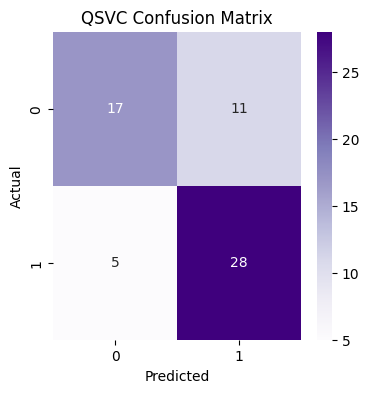

In [ ]:
#Confusion matrix
cm_q = confusion_matrix(y_test, y_pred_q)

plt.figure(figsize=(4,4))
sns.heatmap(cm_q, annot=True, fmt="d", cmap="Purples")
plt.title("QSVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import qiskit
import qiskit_machine_learning
import numpy as np
import sklearn

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)
print("Sklearn:", sklearn.__version__)

Qiskit: 2.3.0
NumPy: 2.2.6
Sklearn: 1.7.2
